In [1]:
# %pip install ipywidgets
# %pip install catboost
# %pip install numpy==1.26.4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 162.5 kB/s eta 0:00:01
     ------------------- ------------------ 30.7/61.0 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 323.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB 1.4 MB/s eta 0:00:12
   ---------------------------------------- 0.0/15.5 MB 653.6 kB/s eta 0:00:24
   ---------------------------------------- 0.1/15.5 MB 657.6 kB/s eta 0:00:24
   ---------------------------------------- 0.1/15.5 MB 654.9 kB/s eta 0:00:24
    --------------------------------------- 0.2/15.5 MB 908.0 kB/s eta 0:00:17
    --------------------------------------- 0.2/15.5 MB 942.1 kB/s eta 0:00:17
    --------------------------------------- 0.3/15.5 MB 999.9 kB/s eta 0:


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
import copy
from sklearn.base import clone as sklearn_clone
from sklearn.metrics import roc_curve
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool

from tqdm.auto import tqdm
from time import time
import shap

import catboost
import sklearn
import joblib

from pathlib import Path

TRAIN_SIZE = 0.8
TARGET = "fraud"
TIME = "step"
TARGET_SPECIFICITY = 0.9985
N_SPLITS = 4
MIN_TRAIN_SIZE = 0.5
SEED = 42
ARTIFACTS = Path(".")

In [5]:
trans = pd.read_csv("../data/transactions.csv")

In [6]:
trans.merchant = trans.merchant.str.strip("'")
trans.customer = trans.customer.str.strip("'")
trans.age = trans.age.str.strip("'")
trans.gender = trans.gender.str.strip("'")
trans.category = trans.category.str.strip("'")

trans = trans.drop(axis=1, columns=["zipcodeOri", "zipMerchant"])

In [5]:
trans

,step,customer,age,gender,merchant,category,amount,fraud
0,0,C1093826151,4,M,M348934600,es_transportation,4.55,0
1,0,C352968107,2,M,M348934600,es_transportation,39.68,0
2,0,C2054744914,4,F,M1823072687,es_transportation,26.89,0
3,0,C1760612790,3,M,M348934600,es_transportation,17.25,0
4,0,C757503768,5,M,M348934600,es_transportation,35.72,0
...,...,...,...,...,...,...,...,...
594638,179,C1753498738,3,F,M1823072687,es_transportation,20.53,0
594639,179,C650108285,4,F,M1823072687,es_transportation,50.73,0
594640,179,C123623130,2,F,M349281107,es_fashion,22.44,0
594641,179,C1499363341,5,M,M1823072687,es_transportation,14.46,0


## Посмотрим на данные

In [6]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   step      594643 non-null  int64  
 1   customer  594643 non-null  object 
 2   age       594643 non-null  object 
 3   gender    594643 non-null  object 
 4   merchant  594643 non-null  object 
 5   category  594643 non-null  object 
 6   amount    594643 non-null  float64
 7   fraud     594643 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 36.3+ MB


Пропуски отсутствуют

Глянем на баланс таргета

In [7]:
trans["fraud"].value_counts()

fraud
0    587443
1      7200
Name: count, dtype: int64

Есть сильный дисбаланс, что соответствует бизнес постановке задачи

Теперь посмотрим на распределение amount

In [ ]:
trans["amount"].describe()

count    594643.000000
mean         37.890135
std         111.402831
min           0.000000
25%          13.740000
50%          26.900000
75%          42.540000
max        8329.960000
Name: amount, dtype: float64

In [ ]:
trans["amount"].quantile([0, .25, .5, .75, .9, .95, .99, .999, 1])

0.000       0.00000
0.250      13.74000
0.500      26.90000
0.750      42.54000
0.900      60.19000
0.950      79.28000
0.990     236.75580
0.999    1031.23478
1.000    8329.96000
Name: amount, dtype: float64

array([[<Axes: title={'center': 'amount'}>]], dtype=object)

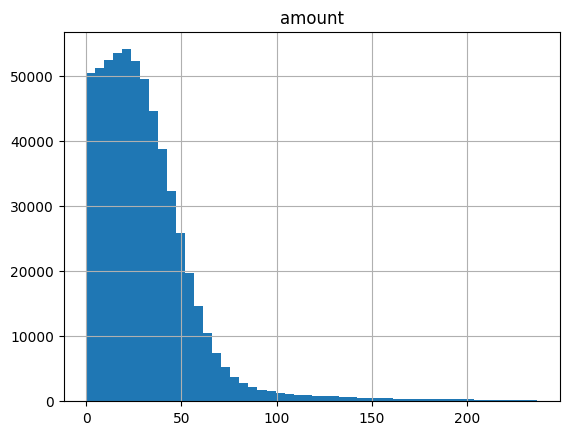

In [ ]:
p99 = trans["amount"].quantile(.99)

trans.loc[trans["amount"] <= p99, ["amount"]].hist(bins=50)

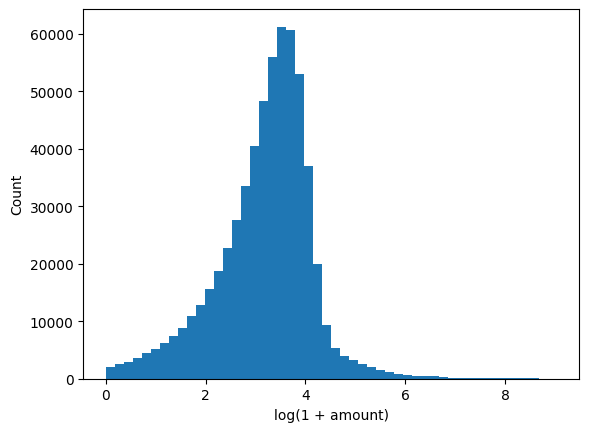

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(np.log1p(trans["amount"]), bins=50)
plt.xlabel("log(1 + amount)")
plt.ylabel("Count")
plt.show()

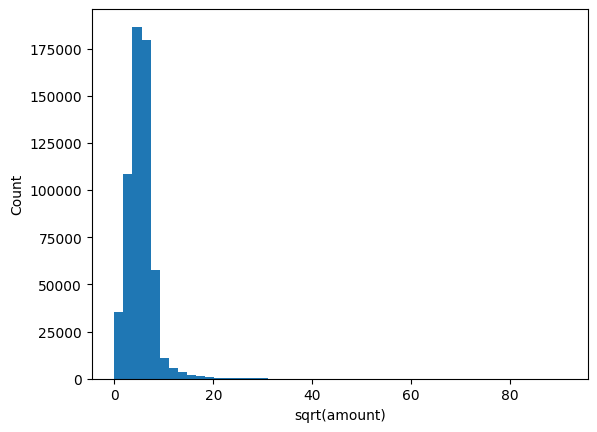

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(np.sqrt(trans["amount"]), bins=50)
plt.xlabel("sqrt(amount)")
plt.ylabel("Count")
plt.show()

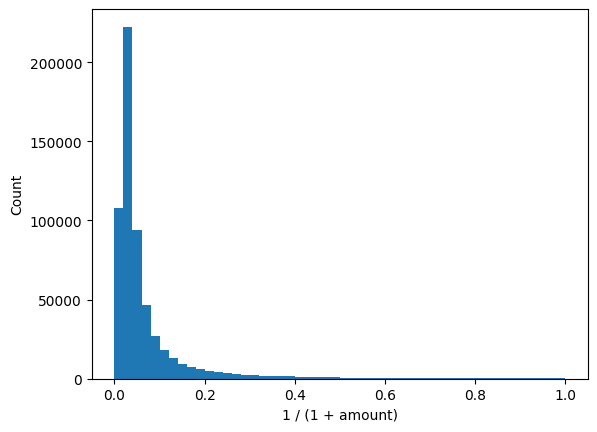

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(1 / (1 + trans["amount"]), bins=50)
plt.xlabel("1 / (1 + amount)")
plt.ylabel("Count")
plt.show()

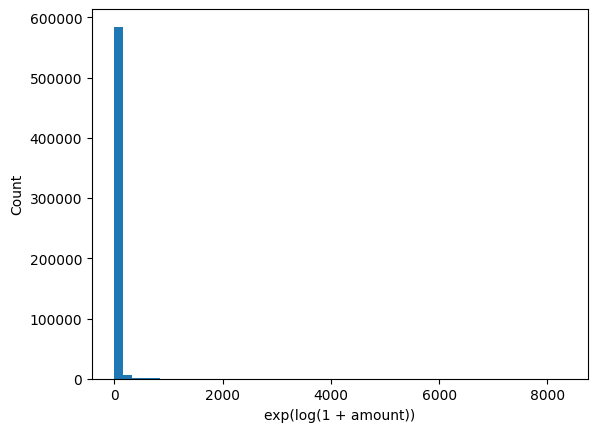

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(np.exp(np.log1p(trans["amount"])), bins=50)
plt.xlabel("exp(log(1 + amount))")
plt.ylabel("Count")
plt.show()

Как и ожидалось, распределение "amount" соответствует распределению Пуасона

Теперь посмотрим на продавцов

In [ ]:
trans["merchant"].value_counts()

merchant
M1823072687    299693
M348934600     205426
M85975013       26254
M1053599405      6821
M151143676       6373
M855959430       6098
M1946091778      5343
M1913465890      3988
M209847108       3814
M480139044       3508
M349281107       2881
M1600850729      2624
M1535107174      1868
M980657600       1769
M78078399        1608
M1198415165      1580
M840466850       1399
M1649169323      1173
M547558035        949
M50039827         916
M1888755466       912
M692898500        900
M1400236507       776
M1842530320       751
M732195782        608
M97925176         599
M45060432         573
M1741626453       528
M1313686961       527
M1872033263       525
M1352454843       370
M677738360        358
M2122776122       341
M923029380        323
M3697346          308
M17379832         282
M1748431652       274
M1873032707       250
M2011752106       244
M1416436880       220
M1294758098       191
M1788569036       181
M857378720        122
M348875670        107
M1353266412        78
M

Есть 2 продавца, которые выполняют около 85% продаж, посмотрим на них подробнее

In [ ]:
trans.loc[trans["merchant"].isin(['M348934600', 'M1823072687'])].groupby(["merchant", "category"]).size()

merchant     category         
M1823072687  es_transportation    299693
M348934600   es_transportation    205426
dtype: int64

То есть 2 самых частых продавца в датасете отвечают за транспортные транзакции. Это связано с тем, что категория Transportation доминирует в исходной статистике, на основе которой калибровался симулятор. Поэтому merchant имеет выраженную кардинальность, но его частотное распределение неравномерно.

Теперь посмотрим на возрастную категорию

In [ ]:
trans.age.value_counts()

age
2    187310
3    147131
4    109025
5     62642
1     58131
6     26774
0      2452
U      1178
Name: count, dtype: int64

In [ ]:
trans.groupby("age")["amount"].sum()

age
0     114270.30
1    2181709.28
2    7184922.84
3    5573280.82
4    4164920.95
5    2281811.97
6     987040.23
U      43147.34
Name: amount, dtype: float64

In [ ]:
trans.groupby("age")["fraud"].mean()

age
0    0.019576
1    0.011853
2    0.012514
3    0.011928
4    0.012933
5    0.010951
6    0.009748
U    0.005942
Name: fraud, dtype: float64

Посмотрим на распределение фродовых транзакций по времени

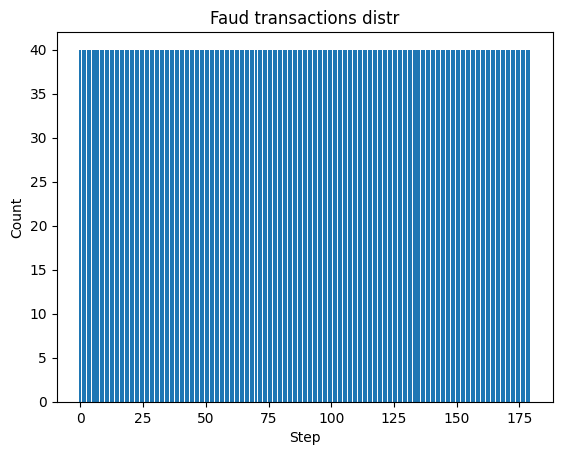

In [ ]:
table = trans.sort_values(["step"]).groupby("step")["fraud"].sum()

plt.bar(table.to_dict().keys(), table.to_dict().values())

plt.title("Faud transactions distr")
plt.xlabel("Step")
plt.ylabel("Count")
plt.show()

На последок глянем на категории товаров

In [ ]:
display(trans.category.value_counts())
display(trans.groupby("category")["amount"].mean())
display(trans.groupby("category")["fraud"].sum())

category
es_transportation        505119
es_food                   26254
es_health                 16133
es_wellnessandbeauty      15086
es_fashion                 6454
es_barsandrestaurants      6373
es_hyper                   6098
es_sportsandtoys           4002
es_tech                    2370
es_home                    1986
es_hotelservices           1744
es_otherservices            912
es_contents                 885
es_travel                   728
es_leisure                  499
Name: count, dtype: int64

category
es_barsandrestaurants      43.461014
es_contents                44.547571
es_fashion                 65.666642
es_food                    37.070405
es_health                 135.621367
es_home                   165.670846
es_hotelservices          205.614249
es_hyper                   45.970421
es_leisure                288.911303
es_otherservices          135.881524
es_sportsandtoys          215.715280
es_tech                   120.947937
es_transportation          26.958187
es_travel                2250.409190
es_wellnessandbeauty       65.511221
Name: amount, dtype: float64

category
es_barsandrestaurants     120
es_contents                 0
es_fashion                116
es_food                     0
es_health                1696
es_home                   302
es_hotelservices          548
es_hyper                  280
es_leisure                474
es_otherservices          228
es_sportsandtoys         1982
es_tech                   158
es_transportation           0
es_travel                 578
es_wellnessandbeauty      718
Name: fraud, dtype: int64

## Перейдем к экспериментам

In [14]:
def make_train_test_split(df, train_size=TRAIN_SIZE):
    TEST_START_STEP = int(df.step.max() * train_size)

    train = df[df[TIME] < TEST_START_STEP].copy()
    test = df[df[TIME] >= TEST_START_STEP].copy()

    print(f"Train: {len(train):,}")
    print(f"Test:  {len(test):,}")

    print(
        f"Train steps: {train[TIME].min()} - {train[TIME].max()}"
    )
    print(
        f"Test steps:  {test[TIME].min()} - {test[TIME].max()}"
    )
    return train, test

Сравним распределение amount на train и test

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179


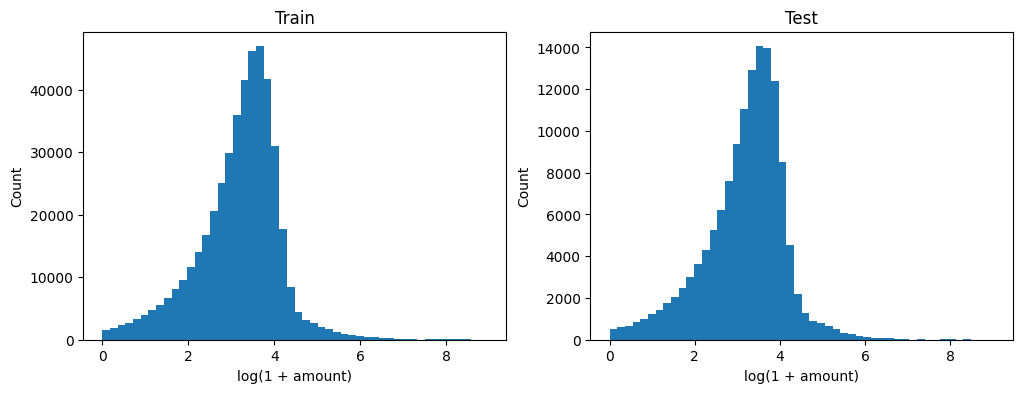

In [7]:
train, test = make_train_test_split(trans, train_size=TRAIN_SIZE)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.log1p(train["amount"]), bins=50)
ax[0].set_title("Train")
ax[0].set_xlabel("log(1 + amount)")
ax[0].set_ylabel("Count")
ax[1].hist(np.log1p(test["amount"]), bins=50)
ax[1].set_title("Test")
ax[1].set_xlabel("log(1 + amount)")
ax[1].set_ylabel("Count")

plt.show()

Распределения похожи. Теперь глянем на распределение fraud

In [ ]:
train, test = make_train_test_split(trans, train_size=TRAIN_SIZE)

print(f"fraud mean on train: {train['fraud'].mean()}")
print(f"fraud mean on test: {test['fraud'].mean()}")

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
fraud mean on train: 0.012496067671012618
fraud mean on test: 0.01081088978005683


In [15]:
def recall_at_specificity(y_true, y_proba, target_specificity=TARGET_SPECIFICITY):
    """
    Максимизирует Recall при условии:
        Specificity >= target_specificity

    Возвращает:
        best_recall
        best_threshold
        best_specificity
    """

    fpr, tpr, thresholds = roc_curve(y_true, y_proba)

    specificity = 1 - fpr
    recall = tpr

    valid = specificity >= target_specificity

    if not np.any(valid):
        return 0.0, 1.0, 0.0

    valid_recall = recall[valid]
    valid_specificity = specificity[valid]
    valid_thresholds = thresholds[valid]

    best_idx = np.argmax(valid_recall)

    best_recall = valid_recall[best_idx]
    best_threshold = valid_thresholds[best_idx]
    best_specificity = valid_specificity[best_idx]

    return best_recall, best_threshold, best_specificity

In [16]:
def create_oot_splits(
    train,
    n_splits=N_SPLITS,
):
    steps = np.sort(train[TIME].unique())
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    oot_splits = []
    
    for fold, (train_step_idx, val_step_idx) in enumerate(tscv.split(steps), start=1):
        train_steps = steps[train_step_idx]
        val_steps = steps[val_step_idx]
    
        train_idx = train.index[
            train[TIME].isin(train_steps)
        ]
    
        val_idx = train.index[
            train[TIME].isin(val_steps)
        ]
    
        oot_splits.append((train_idx, val_idx))
    
        print(
            f"Fold {fold}: "
            f"train step {train_steps[0]}-{train_steps[-1]} "
            f"({len(train_idx):,} transactions), "
            f"val step {val_steps[0]}-{val_steps[-1]} "
            f"({len(val_idx):,} transactions)"
        )

    return oot_splits

In [17]:
def safe_clone(estimator):
    """
    Аналог sklearn.clone, но использует deepcopy вместо
    реконструкции через get_params/set_params.
    Нужен для CatBoost и других моделей, у которых
    get_params() не идентичен параметрам конструктора
    (из-за чего sklearn.clone падает с RuntimeError).
    """
    try:
        return sklearn_clone(estimator)
    except RuntimeError:
        return copy.deepcopy(estimator)

In [5]:
def make_experiment(
    df,
    numerical_features,
    categorical_features,
    model,
    param_grid,
    train_size=TRAIN_SIZE,
    experiment_name="experiment",
    n_splits=N_SPLITS
):
    features = numerical_features + categorical_features

    df = df.loc[
        :,
        features + ["fraud"]
    ].copy()

    train, test = make_train_test_split(
        df,
        train_size
    )

    X_train = train.drop(columns="fraud")
    y_train = train["fraud"]

    X_test = test.drop(columns="fraud")
    y_test = test["fraud"]

    oot_splits = create_oot_splits(train, n_splits)

    grid_results = []

    param_list = list(ParameterGrid(param_grid))

    for params in tqdm(
        param_list,
        desc="Grid search",
        total=len(param_list)
    ):

        fold_results = []

        for fold, (train_idx, val_idx) in tqdm(
            enumerate(oot_splits, start=1),
            desc=f"  Folds ({params})",
            total=len(oot_splits),
            leave=False
        ):

            X_fold_train = X_train.loc[train_idx]
            y_fold_train = y_train.loc[train_idx]

            X_fold_val = X_train.loc[val_idx]
            y_fold_val = y_train.loc[val_idx]

            fold_model = safe_clone(model)
            
            fold_model.set_params(
                **params
            )

            fold_model.fit(
                X_fold_train,
                y_fold_train
            )

            val_proba = fold_model.predict_proba(
                X_fold_val
            )[:, 1]

            recall, threshold, specificity = (
                recall_at_specificity(
                    y_fold_val,
                    val_proba
                )
            )

            fold_results.append({
                "fold": fold,
                "recall": recall,
                "specificity": specificity,
                "threshold": threshold
            })

        fold_results = pd.DataFrame(
            fold_results
        )

        grid_results.append({
            "params": params,

            "mean_recall": (
                fold_results["recall"].mean()
            ),

            "std_recall": (
                fold_results["recall"].std()
            ),

            "mean_specificity": (
                fold_results["specificity"].mean()
            )
        })

    grid_results = pd.DataFrame(
        grid_results
    )

    best_result = grid_results.sort_values(
        [
            "mean_recall",
            "mean_specificity"
        ],
        ascending=False
    ).iloc[0]

    best_params = best_result["params"]
    best_model = safe_clone(model)

    best_model.set_params(
        **best_params
    )

    oof_predictions = pd.Series(
        index=X_train.index,
        dtype=float
    )

    for train_idx, val_idx in tqdm(
        oot_splits,
        desc="OOF predictions",
        total=len(oot_splits)
    ):

        X_fold_train = X_train.loc[train_idx]
        y_fold_train = y_train.loc[train_idx]

        X_fold_val = X_train.loc[val_idx]

        fold_model = safe_clone(best_model)

        fold_model.fit(
            X_fold_train,
            y_fold_train
        )

        oof_predictions.loc[val_idx] = (
            fold_model.predict_proba(
                X_fold_val
            )[:, 1]
        )

    valid_oof = oof_predictions.notna()

    oof_recall, threshold, oof_specificity = (
        recall_at_specificity(
            y_train.loc[valid_oof],
            oof_predictions.loc[valid_oof]
        )
    )

    final_model = safe_clone(best_model)

    final_model.fit(
        X_train,
        y_train
    )

    test_proba = final_model.predict_proba(
        X_test
    )[:, 1]

    test_pred = (
        test_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        test_pred,
        labels=[0, 1]
    ).ravel()

    test_recall = (
        tp / (tp + fn)
    )

    test_specificity = (
        tn / (tn + fp)
    )

    test_precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    result = {
        "experiment": experiment_name,

        "model": type(
            model[-1]
        ).__name__,

        "params": best_params,

        "cv_recall_mean": best_result["mean_recall"],

        "oof_recall": oof_recall,

        "test_recall": test_recall,
        "test_specificity": test_specificity,
        "test_precision": test_precision,

        "threshold": threshold
    }

    return final_model, result, grid_results

In [13]:
experiments = pd.read_csv("./experiments.csv")
experiments

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold,cv_recall_std,train_recall,train_cv_recall_gap,train_test_recall_gap,fraud_amount_recall
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280,NaN,NaN,NaN,NaN,NaN
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761,NaN,NaN,NaN,NaN,NaN
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074,NaN,NaN,NaN,NaN,NaN
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021,NaN,NaN,NaN,NaN,NaN
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018,NaN,NaN,NaN,NaN,NaN
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132,NaN,NaN,NaN,NaN,NaN
6,catboost_4,CatBoostClassifier,"{'model__depth': 8, 'model__iterations': 1000,...",0.760491,0.756696,0.818243,0.998272,0.838062,0.940894,NaN,NaN,NaN,NaN,NaN
7,catboost_5,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.726339,0.722991,0.766892,0.998567,0.854026,0.973415,NaN,NaN,NaN,NaN,NaN
8,catboost_6,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.696652,0.694196,0.648649,0.999262,0.905660,0.978048,NaN,NaN,NaN,NaN,NaN
9,catboost_5.1,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.1, 'iterations...",0.448661,0.227679,0.000000,1.000000,0.000000,0.889339,NaN,NaN,NaN,NaN,NaN


## Эксперимент 1

In [ ]:
categorical_features = [
    "age",
    "gender",
    "category"
]

numerical_features = [
    "amount",
    "step"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

logreg_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

logreg_grid = {
    "model__C": [
        0.01,
        0.1,
        1.0,
        10.0
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    model=logreg_pipeline,
    param_grid=logreg_grid,
    experiment_name="logreg_1"
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 0.01}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 0.1}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 1.0}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 10.0}):   0%|          | 0/4 [00:00<?, ?it/s]

OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.98228


In [ ]:
categorical_features = [
    "age",
    "gender",
    "category"
]

numerical_features = [
    "amount",
    "step",
]

catboost_pipeline = Pipeline([
    (
        "model",
        CatBoostClassifier(
            cat_features=categorical_features,
            auto_class_weights="Balanced",
            verbose=False,
            random_state=42
        )
    )
])

catboost_grid = {
    "model__depth": [
        4,
        6,
    ],
    "model__learning_rate": [
        0.03,
        0.1
    ],
    "model__iterations": [
        300
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    model=catboost_pipeline,
    param_grid=catboost_grid,
    experiment_name="catboost_1"
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__depth': 4, 'model__iterations': 300, 'model__learning_rate': 0.03}):   0%|          | 0/4 [0…

  Folds ({'model__depth': 4, 'model__iterations': 300, 'model__learning_rate': 0.1}):   0%|          | 0/4 [00…

  Folds ({'model__depth': 6, 'model__iterations': 300, 'model__learning_rate': 0.03}):   0%|          | 0/4 [0…

  Folds ({'model__depth': 6, 'model__iterations': 300, 'model__learning_rate': 0.1}):   0%|          | 0/4 [00…

OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761


## Эксперимент 2

Добавим к каждой строке агрегирование по средней сумме транзакций, дисперсию суммы транзакций и количеству этих самых транзакций пользователя за предыдущий шаг. Также добавим отношение суммы текущей транзакции к средней сумме за прошлый шаг и время с последней транзакции.

In [ ]:
trans = trans.sort_values(["customer", "step"]).copy()

customer_step_stats = (
    trans
    .groupby(["customer", "step"])["amount"]
    .agg(
        customer_transaction_count_prev_step="count",
        customer_avg_amount_prev_step="mean",
        customer_std_amount_prev_step="std"
    )
    .reset_index()
)

customer_step_stats = customer_step_stats.sort_values(["customer", "step"])

customer_step_stats[
    [
        "customer_transaction_count_prev_step",
        "customer_avg_amount_prev_step",
        "customer_std_amount_prev_step",
    ]
] = (
    customer_step_stats
    .groupby("customer")[
        [
            "customer_transaction_count_prev_step",
            "customer_avg_amount_prev_step",
            "customer_std_amount_prev_step",
        ]
    ]
    .shift(1)
)

customer_step_stats["prev_transaction_step"] = (
    customer_step_stats
    .groupby("customer")["step"]
    .shift(1)
)

trans = trans.merge(
    customer_step_stats,
    on=["customer", "step"],
    how="left"
)

trans["customer_time_since_last_transaction"] = (
    trans["step"] - trans["prev_transaction_step"]
)
trans = trans.drop(columns=["prev_transaction_step"])

avg = trans["customer_avg_amount_prev_step"]
trans["amount_to_customer_avg_amount"] = np.where(
    avg > 0,
    trans["amount"] / avg,
    np.nan
)

trans["amount_to_customer_avg_amount"] = (
    trans["amount_to_customer_avg_amount"]
    .replace([np.inf, -np.inf], np.nan)
)

trans["has_customer_history"] = (
    trans["customer_transaction_count_prev_step"].notna().astype(int)
)

history_features = [
    "customer_transaction_count_prev_step",
    "customer_avg_amount_prev_step",
    "customer_std_amount_prev_step",
    "customer_time_since_last_transaction",
    "amount_to_customer_avg_amount",
]

trans[history_features] = trans[history_features].fillna(0)

In [ ]:
trans

,step,customer,age,gender,merchant,category,amount,fraud,customer_transaction_count_prev_step,customer_avg_amount_prev_step,customer_std_amount_prev_step,customer_time_since_last_transaction,amount_to_customer_avg_amount,has_customer_history
0,30,C1000148617,5,M,M1888755466,es_otherservices,143.87,0,0.0,0.00,0.0,0.0,0.000000,0
1,38,C1000148617,5,M,M1741626453,es_sportsandtoys,16.69,0,1.0,143.87,0.0,8.0,0.116008,1
2,42,C1000148617,5,M,M1888755466,es_otherservices,56.18,0,1.0,16.69,0.0,4.0,3.366087,1
3,43,C1000148617,5,M,M840466850,es_tech,14.74,0,1.0,56.18,0.0,1.0,0.262371,1
4,44,C1000148617,5,M,M1823072687,es_transportation,47.42,0,1.0,14.74,0.0,1.0,3.217096,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594638,174,C999723254,2,M,M1823072687,es_transportation,31.94,0,1.0,19.08,0.0,1.0,1.674004,1
594639,176,C999723254,2,M,M1823072687,es_transportation,1.92,0,1.0,31.94,0.0,2.0,0.060113,1
594640,177,C999723254,2,M,M85975013,es_food,62.55,0,1.0,1.92,0.0,1.0,32.578125,1
594641,178,C999723254,2,M,M1823072687,es_transportation,25.96,0,1.0,62.55,0.0,1.0,0.415028,1


In [ ]:
categorical_features = [
    "age",
    "gender",
    "category"
]

numerical_features = [
    "amount",
    "step",
    "has_customer_history"
]

numerical_features += history_features

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

logreg_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

logreg_grid = {
    "model__C": [
        0.01,
        0.1,
        1.0,
        10.0
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    model=logreg_pipeline,
    param_grid=logreg_grid,
    experiment_name="logreg_2"
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 0.01}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 0.1}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 1.0}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 10.0}):   0%|          | 0/4 [00:00<?, ?it/s]

OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074


In [ ]:
catboost_pipeline = Pipeline([
    (
        "model",
        CatBoostClassifier(
            cat_features=categorical_features,
            auto_class_weights="Balanced",
            verbose=False,
            random_state=42
        )
    )
])

catboost_grid = {
    "model__depth": [
        4,
        6,
        8
    ],
    "model__learning_rate": [
        0.03,
        0.1
    ],
    "model__iterations": [
        300
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    model=catboost_pipeline,
    param_grid=catboost_grid,
    experiment_name="catboost_2"
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/6 [00:00<?, ?it/s]

  Folds ({'model__depth': 4, 'model__iterations': 300, 'model__learning_rate': 0.03}):   0%|          | 0/4 [0…

  Folds ({'model__depth': 4, 'model__iterations': 300, 'model__learning_rate': 0.1}):   0%|          | 0/4 [00…

  Folds ({'model__depth': 6, 'model__iterations': 300, 'model__learning_rate': 0.03}):   0%|          | 0/4 [0…

  Folds ({'model__depth': 6, 'model__iterations': 300, 'model__learning_rate': 0.1}):   0%|          | 0/4 [00…

  Folds ({'model__depth': 8, 'model__iterations': 300, 'model__learning_rate': 0.03}):   0%|          | 0/4 [0…

  Folds ({'model__depth': 8, 'model__iterations': 300, 'model__learning_rate': 0.1}):   0%|          | 0/4 [00…

OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021


## Эксперимент 3

Добавим логарифмирование к числовым признакам

In [ ]:
passthrough_features = [
    "step",
    "has_customer_history"
]

log1p_features = [
    "amount",
    "customer_transaction_count_prev_step",
    "customer_avg_amount_prev_step",
    "customer_std_amount_prev_step",
    "customer_time_since_last_transaction",
    "amount_to_customer_avg_amount"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "passthrough_num",
            StandardScaler(),
            passthrough_features
        ),
        (
            "log1p_num",
            Pipeline([
                ("log1p", FunctionTransformer(np.log1p, validate=True)),
                ("scale", StandardScaler())
            ]),
            log1p_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

logreg_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

logreg_grid = {
    "model__C": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    model=logreg_pipeline,
    param_grid=logreg_grid,
    experiment_name="logreg_3"
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/5 [00:00<?, ?it/s]

  Folds ({'model__C': 0.001}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 0.01}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 0.1}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 1.0}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 10.0}):   0%|          | 0/4 [00:00<?, ?it/s]

OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018


## Эксперимент 4

Добавим агрегированную информацию продавцов, а также попробуем увеличить количество деревьев в catboost

In [ ]:
trans = trans.sort_values(["merchant", "step"]).copy()


merchant_step_stats = (
    trans
    .groupby(["merchant", "step"])["amount"]
    .agg(
        merchant_transaction_count_prev_step="count",
        merchant_avg_amount_prev_step="mean",
        merchant_std_amount_prev_step="std"
    )
    .reset_index()
)


merchant_step_stats = merchant_step_stats.sort_values(
    ["merchant", "step"]
)

merchant_step_stats[
    [
        "merchant_transaction_count_prev_step",
        "merchant_avg_amount_prev_step",
        "merchant_std_amount_prev_step",
    ]
] = (
    merchant_step_stats
    .groupby("merchant")[
        [
            "merchant_transaction_count_prev_step",
            "merchant_avg_amount_prev_step",
            "merchant_std_amount_prev_step",
        ]
    ]
    .shift(1)
)

merchant_step_stats["prev_transaction_step"] = (
    merchant_step_stats
    .groupby("merchant")["step"]
    .shift(1)
)

trans = trans.merge(
    merchant_step_stats,
    on=["merchant", "step"],
    how="left"
)

trans["merchant_time_since_last_transaction"] = (
    trans["step"] - trans["prev_transaction_step"]
)
trans = trans.drop(
    columns=["prev_transaction_step"]
)

merchant_customer_stats = (
    trans
    .groupby(["merchant", "step"])["customer"]
    .nunique()
    .reset_index(
        name="merchant_unique_customers_prev_step"
    )
)
merchant_customer_stats = merchant_customer_stats.sort_values(
    ["merchant", "step"]
)
merchant_customer_stats[
    "merchant_unique_customers_prev_step"
] = (
    merchant_customer_stats
    .groupby("merchant")[
        "merchant_unique_customers_prev_step"
    ]
    .shift(1)
)
trans = trans.merge(
    merchant_customer_stats,
    on=["merchant", "step"],
    how="left"
)

avg = trans["merchant_avg_amount_prev_step"]
trans["amount_to_merchant_avg_amount"] = np.where(
    avg > 0,
    trans["amount"] / avg,
    np.nan
)

trans["has_merchant_history"] = (
    trans["merchant_transaction_count_prev_step"]
    .notna()
    .astype(int)
)

trans["amount_to_merchant_avg_amount"] = (
    trans["amount_to_merchant_avg_amount"]
    .replace([np.inf, -np.inf], np.nan)
)

merchant_history_features = [
    "merchant_transaction_count_prev_step",
    "merchant_avg_amount_prev_step",
    "merchant_std_amount_prev_step",
    "merchant_time_since_last_transaction",
    "merchant_unique_customers_prev_step",
    "amount_to_merchant_avg_amount",
]

trans[merchant_history_features] = (
    trans[merchant_history_features]
    .fillna(0)
)

In [ ]:
categorical_features = [
    "age",
    "gender",
    "category"
]

numerical_features = [
    "amount",
    "step",
    "has_customer_history",
    "has_merchant_history"
]

numerical_features += history_features
numerical_features += merchant_history_features

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

logreg_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

logreg_grid = {
    "model__C": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    model=logreg_pipeline,
    param_grid=logreg_grid,
    experiment_name="logreg_4"
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/5 [00:00<?, ?it/s]

  Folds ({'model__C': 0.001}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 0.01}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 0.1}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 1.0}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'model__C': 10.0}):   0%|          | 0/4 [00:00<?, ?it/s]

OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132


In [ ]:
catboost_pipeline = Pipeline([
    (
        "model",
        CatBoostClassifier(
            cat_features=categorical_features,
            auto_class_weights="Balanced",
            verbose=False,
            random_state=42
        )
    )
])

catboost_grid = {
    "model__depth": [
        4,
        6,
        8
    ],
    "model__learning_rate": [
        0.03,
        0.1,
        0.01
    ],
    "model__iterations": [
        300,
        1000
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    model=catboost_pipeline,
    param_grid=catboost_grid,
    experiment_name="catboost_4"
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/18 [00:00<?, ?it/s]

  Folds ({'model__depth': 4, 'model__iterations': 300, 'model__learning_rate': 0.03}):   0%|          | 0/4 [0…

  Folds ({'model__depth': 4, 'model__iterations': 300, 'model__learning_rate': 0.1}):   0%|          | 0/4 [00…

  Folds ({'model__depth': 4, 'model__iterations': 300, 'model__learning_rate': 0.01}):   0%|          | 0/4 [0…

...

  Folds ({'model__depth': 8, 'model__iterations': 300, 'model__learning_rate': 0.01}):   0%|          | 0/4 [0…

  Folds ({'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}):   0%|          | 0/4 […

  Folds ({'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.1}):   0%|          | 0/4 [0…

  Folds ({'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.01}):   0%|          | 0/4 […

OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132
6,catboost_4,CatBoostClassifier,"{'model__depth': 8, 'model__iterations': 1000,...",0.760491,0.756696,0.818243,0.998272,0.838062,0.940894


In [ ]:
final_model["model"].save_model("catboost4.cbm")

## Основные эксперименты CATBOOST

In [5]:
def make_customer_agg_features(trans):
    trans = trans.sort_values(["customer", "step"]).copy()

    customer_step_stats = (
        trans
        .groupby(["customer", "step"])["amount"]
        .agg(
            customer_transaction_count_prev_step="count",
            customer_avg_amount_prev_step="mean",
            customer_std_amount_prev_step="std"
        )
        .reset_index()
    )

    customer_step_stats = customer_step_stats.sort_values(["customer", "step"])

    customer_step_stats[
        [
            "customer_transaction_count_prev_step",
            "customer_avg_amount_prev_step",
            "customer_std_amount_prev_step",
        ]
    ] = (
        customer_step_stats
        .groupby("customer")[
            [
                "customer_transaction_count_prev_step",
                "customer_avg_amount_prev_step",
                "customer_std_amount_prev_step",
            ]
        ]
        .shift(1)
    )

    customer_step_stats["prev_transaction_step"] = (
        customer_step_stats
        .groupby("customer")["step"]
        .shift(1)
    )

    trans = trans.merge(
        customer_step_stats,
        on=["customer", "step"],
        how="left"
    )

    trans["customer_time_since_last_transaction"] = (
        trans["step"] - trans["prev_transaction_step"]
    )
    trans = trans.drop(columns=["prev_transaction_step"])

    avg = trans["customer_avg_amount_prev_step"]
    trans["amount_to_customer_avg_amount"] = np.where(
        avg > 0,
        trans["amount"] / avg,
        np.nan
    )

    trans["amount_to_customer_avg_amount"] = (
        trans["amount_to_customer_avg_amount"]
        .replace([np.inf, -np.inf], np.nan)
    )

    trans["has_customer_history"] = (
        trans["customer_transaction_count_prev_step"].notna().astype(int)
    )

    customer_history_features = [
        "customer_transaction_count_prev_step",
        "customer_avg_amount_prev_step",
        "customer_std_amount_prev_step",
        "customer_time_since_last_transaction",
        "amount_to_customer_avg_amount",
    ]

    trans[customer_history_features] = trans[customer_history_features].fillna(0)

    customer_history_features.append("has_customer_history")
    return trans, customer_history_features

In [6]:
def make_merchant_agg_features(trans):
    trans = trans.sort_values(["merchant", "step"]).copy()
    merchant_step_stats = (
        trans
        .groupby(["merchant", "step"])["amount"]
        .agg(
            merchant_transaction_count_prev_step="count",
            merchant_avg_amount_prev_step="mean",
            merchant_std_amount_prev_step="std"
        )
        .reset_index()
    )


    merchant_step_stats = merchant_step_stats.sort_values(
        ["merchant", "step"]
    )

    merchant_step_stats[
        [
            "merchant_transaction_count_prev_step",
            "merchant_avg_amount_prev_step",
            "merchant_std_amount_prev_step",
        ]
    ] = (
        merchant_step_stats
        .groupby("merchant")[
            [
                "merchant_transaction_count_prev_step",
                "merchant_avg_amount_prev_step",
                "merchant_std_amount_prev_step",
            ]
        ]
        .shift(1)
    )

    merchant_step_stats["prev_transaction_step"] = (
        merchant_step_stats
        .groupby("merchant")["step"]
        .shift(1)
    )

    trans = trans.merge(
        merchant_step_stats,
        on=["merchant", "step"],
        how="left"
    )

    trans["merchant_time_since_last_transaction"] = (
        trans["step"] - trans["prev_transaction_step"]
    )
    trans = trans.drop(
        columns=["prev_transaction_step"]
    )

    merchant_customer_stats = (
        trans
        .groupby(["merchant", "step"])["customer"]
        .nunique()
        .reset_index(
            name="merchant_unique_customers_prev_step"
        )
    )
    merchant_customer_stats = merchant_customer_stats.sort_values(
        ["merchant", "step"]
    )
    merchant_customer_stats[
        "merchant_unique_customers_prev_step"
    ] = (
        merchant_customer_stats
        .groupby("merchant")[
            "merchant_unique_customers_prev_step"
        ]
        .shift(1)
    )
    trans = trans.merge(
        merchant_customer_stats,
        on=["merchant", "step"],
        how="left"
    )

    avg = trans["merchant_avg_amount_prev_step"]
    trans["amount_to_merchant_avg_amount"] = np.where(
        avg > 0,
        trans["amount"] / avg,
        np.nan
    )

    trans["has_merchant_history"] = (
        trans["merchant_transaction_count_prev_step"]
        .notna()
        .astype(int)
    )

    trans["amount_to_merchant_avg_amount"] = (
        trans["amount_to_merchant_avg_amount"]
        .replace([np.inf, -np.inf], np.nan)
    )

    merchant_history_features = [
        "merchant_transaction_count_prev_step",
        "merchant_avg_amount_prev_step",
        "merchant_std_amount_prev_step",
        "merchant_time_since_last_transaction",
        "merchant_unique_customers_prev_step",
        "amount_to_merchant_avg_amount",
    ]

    trans[merchant_history_features] = (
        trans[merchant_history_features]
        .fillna(0)
    )

    merchant_history_features.append("has_merchant_history")
    return trans, merchant_history_features

In [19]:
def make_features(trans):
    trans, customer_history_features = make_customer_agg_features(trans)
    trans, merchant_history_features = make_merchant_agg_features(trans)

    start_date = pd.Timestamp("2026-01-01")
    trans["date"] = start_date + pd.to_timedelta(
        trans["step"],
        unit="D"
    )
    trans["day_of_week"] = trans["date"].dt.dayofweek
    trans["month"] = trans["date"].dt.month
    trans["day_of_week_cat"] = trans["date"].dt.dayofweek.astype(str)
    trans["month_cat"] = trans["date"].dt.month.astype(str)

    date_features = ["day_of_week", "month"]
    date_cat_features = ["day_of_week_cat", "month_cat"]

    print(customer_history_features)
    print(merchant_history_features)
    print(date_features)
    print(date_cat_features)

    history_features = customer_history_features + merchant_history_features

    return trans, history_features, date_features, date_cat_features


In [20]:
trans = pd.read_csv("../data/transactions.csv")

trans.merchant = trans.merchant.str.strip("'")
trans.customer = trans.customer.str.strip("'")
trans.age = trans.age.str.strip("'")
trans.gender = trans.gender.str.strip("'")
trans.category = trans.category.str.strip("'")
trans = trans.drop(axis=1, columns=["zipcodeOri", "zipMerchant"])

trans, history_features, date_features, date_cat_features = make_features(trans)

['customer_transaction_count_prev_step', 'customer_avg_amount_prev_step', 'customer_std_amount_prev_step', 'customer_time_since_last_transaction', 'amount_to_customer_avg_amount', 'has_customer_history']
['merchant_transaction_count_prev_step', 'merchant_avg_amount_prev_step', 'merchant_std_amount_prev_step', 'merchant_time_since_last_transaction', 'merchant_unique_customers_prev_step', 'amount_to_merchant_avg_amount', 'has_merchant_history']
['day_of_week', 'month']
['day_of_week_cat', 'month_cat']


In [9]:
def set_seeds(seed=SEED):
    np.random.seed(seed)

set_seeds(SEED)

In [10]:
def _fit_model(
    model,
    X_train,
    y_train,
    X_val=None,
    y_val=None,
    early_stopping_rounds=50
):
    """
    Обучает модель. Для CatBoostClassifier с переданным
    eval_set включает early stopping и возвращает
    best_iteration (None, если модель не CatBoost или
    eval_set не передан).
    """

    if X_val is not None:
        model.fit(
            X_train,
            y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=early_stopping_rounds,
            use_best_model=True,
            verbose=False
        )
        best_iteration = model.get_best_iteration()
    else:
        model.fit(
            X_train,
            y_train
        )
        best_iteration = None

    return model, best_iteration

def compute_fraud_amount_recall(y_true, y_pred, amounts):
    """
    Доля суммарного объёма (amount) фрод-транзакций,
    которые модель верно определила как fraud.
    Отличается от recall по количеству транзакций тем,
    что взвешивает каждую транзакцию по её сумме —
    релевантно, когда пропустить крупный fraud
    дороже, чем пропустить мелкий.
    """
    fraud_mask = (y_true == 1)

    total_fraud_amount = amounts[fraud_mask].sum()

    if total_fraud_amount == 0:
        return np.nan

    caught_fraud_amount = amounts[
        fraud_mask & (y_pred == 1)
    ].sum()

    return caught_fraud_amount / total_fraud_amount


def evaluate_experiment(
    y_train,
    train_proba,
    y_test,
    test_proba,
    test_amounts,
    threshold,
    best_result,
):
    """
    Считает полный набор метрик для одного эксперимента:
      - core-метрики (recall/specificity/precision на test)
      - overfitting-диагностика (train vs cv/test gap)
      - бизнес-метрика (fraud amount recall)

    best_result — строка из grid_results с лучшей комбинацией
    параметров (даёт cv_recall_mean и cv_recall_std).
    """

    train_pred = (train_proba >= threshold).astype(int)

    train_tn, train_fp, train_fn, train_tp = confusion_matrix(
        y_train,
        train_pred,
        labels=[0, 1]
    ).ravel()

    train_recall = (
        train_tp / (train_tp + train_fn)
        if (train_tp + train_fn) > 0
        else 0
    )

    cv_recall_mean = best_result["mean_recall"]
    cv_recall_std = best_result["std_recall"]

    train_cv_recall_gap = train_recall - cv_recall_mean

    test_pred = (test_proba >= threshold).astype(int)
    test_tn, test_fp, test_fn, test_tp = confusion_matrix(
        y_test,
        test_pred,
        labels=[0, 1]
    ).ravel()

    test_recall = (
        test_tp / (test_tp + test_fn)
        if (test_tp + test_fn) > 0
        else 0
    )

    test_specificity = (
        test_tn / (test_tn + test_fp)
        if (test_tn + test_fp) > 0
        else 0
    )

    test_precision = (
        test_tp / (test_tp + test_fp)
        if (test_tp + test_fp) > 0
        else 0
    )

    train_test_recall_gap = train_recall - test_recall

    fraud_amount_recall = compute_fraud_amount_recall(
        y_test,
        test_pred,
        test_amounts
    )

    return {
        "cv_recall_mean": cv_recall_mean,
        "cv_recall_std": cv_recall_std,

        "train_recall": train_recall,
        "train_cv_recall_gap": train_cv_recall_gap,
        "train_test_recall_gap": train_test_recall_gap,

        "test_recall": test_recall,
        "test_specificity": test_specificity,
        "test_precision": test_precision,

        "fraud_amount_recall": fraud_amount_recall,

        "threshold": threshold
    }

def make_experiment(
    df,
    num_features,
    cat_features,
    model,
    param_grid,
    train_size=TRAIN_SIZE,
    experiment_name="experiment",
    n_splits=N_SPLITS,
    use_early_stopping=True,
    early_stopping_rounds=50,
    amount_col="amount",
    seed=SEED
):
    features = num_features + cat_features
    start_params = model.get_params()

    train, test = make_train_test_split(
        df,
        train_size
    )

    X_train = train.loc[:, features].copy()
    X_test = test.loc[:, features].copy()
    y_train = train["fraud"]
    y_test = test["fraud"]

    test_amounts = test[amount_col]

    oot_splits = create_oot_splits(train, n_splits)

    grid_results = []
    param_list = list(ParameterGrid(param_grid))
    for params in tqdm(
        param_list,
        desc="Grid search",
        total=len(param_list)
    ):

        fold_results = []

        for fold, (train_idx, val_idx) in tqdm(
            enumerate(oot_splits, start=1),
            desc=f"  Folds ({params})",
            total=len(oot_splits),
            leave=False
        ):
            X_fold_train = X_train.loc[train_idx]
            y_fold_train = y_train.loc[train_idx]

            X_fold_val = X_train.loc[val_idx]
            y_fold_val = y_train.loc[val_idx]

            fold_model = safe_clone(model)
            fold_model.set_params(
                **params
            )
            fold_model, best_iteration = _fit_model(
                fold_model,
                X_fold_train,
                y_fold_train,
                X_val=X_fold_val if use_early_stopping else None,
                y_val=y_fold_val if use_early_stopping else None,
                early_stopping_rounds=early_stopping_rounds
            )

            val_proba = fold_model.predict_proba(
                X_fold_val
            )[:, 1]

            recall, threshold, specificity = (
                recall_at_specificity(
                    y_fold_val,
                    val_proba
                )
            )

            fold_results.append({
                "fold": fold,
                "recall": recall,
                "specificity": specificity,
                "threshold": threshold,
                "best_iteration": best_iteration
            })

        fold_results = pd.DataFrame(
            fold_results
        )

        grid_results.append({
            "params": params,

            "mean_recall": (
                fold_results["recall"].mean()
            ),

            "std_recall": (
                fold_results["recall"].std()
            ),

            "mean_specificity": (
                fold_results["specificity"].mean()
            ),

            "median_best_iteration": (
                fold_results["best_iteration"].median()
            )
        })

    grid_results = pd.DataFrame(
        grid_results
    )

    best_result = grid_results.sort_values(
        [
            "mean_recall",
            "mean_specificity"
        ],
        ascending=False
    ).iloc[0]

    best_params = dict(best_result["params"])
    best_model = safe_clone(model)
    best_model.set_params(
        **best_params
    )

    oof_predictions = pd.Series(
        index=X_train.index,
        dtype=float
    )

    oof_best_iterations = []
    for train_idx, val_idx in tqdm(
        oot_splits,
        desc="OOF predictions",
        total=len(oot_splits)
    ):
        X_fold_train = X_train.loc[train_idx]
        y_fold_train = y_train.loc[train_idx]

        X_fold_val = X_train.loc[val_idx]
        y_fold_val = y_train.loc[val_idx]

        fold_model = safe_clone(best_model)
        fold_model, best_iteration = _fit_model(
            fold_model,
            X_fold_train,
            y_fold_train,
            X_val=X_fold_val if use_early_stopping else None,
            y_val=y_fold_val if use_early_stopping else None,
            early_stopping_rounds=early_stopping_rounds
        )

        if best_iteration is not None:
            oof_best_iterations.append(best_iteration)

        oof_predictions.loc[val_idx] = (
            fold_model.predict_proba(
                X_fold_val
            )[:, 1]
        )

    valid_oof = oof_predictions.notna()
    oof_recall, threshold, oof_specificity = (
        recall_at_specificity(
            y_train.loc[valid_oof],
            oof_predictions.loc[valid_oof]
        )
    )

    final_model = safe_clone(best_model)
    final_iterations = None

    if use_early_stopping and len(oof_best_iterations) > 0:
        final_iterations = int(
            np.median(oof_best_iterations)
        )
        final_model.set_params(
            iterations=final_iterations
        )

    final_model, _ = _fit_model(
        final_model,
        X_train,
        y_train
    )

    train_proba = final_model.predict_proba(
        X_train
    )[:, 1]

    test_proba = final_model.predict_proba(
        X_test
    )[:, 1]

    metrics = evaluate_experiment(
        y_train=y_train,
        train_proba=train_proba,
        y_test=y_test,
        test_proba=test_proba,
        test_amounts=test_amounts,
        threshold=threshold,
        best_result=best_result
    )

    if final_iterations is not None:
        best_params["iterations"] = final_iterations

    result = {
        "experiment": experiment_name,
        "model": type(model).__name__,
        "params": best_params,
        "oof_recall": oof_recall,
        **metrics
    }
    metadata = {
        "model_name": type(final_model).__name__,
        "model_version": experiment_name.split("_")[-1],
        "start_params": start_params,
        "grid_params": param_grid,
        "trained_at": pd.Timestamp.utcnow().isoformat(timespec="seconds"),
        "n_train": int(len(X_train)),
        "features": features,
        "numerical_features": num_features,
        "categorical_features": cat_features,
        "use_early_stopping": use_early_stopping,
        "early_stopping_rounds": early_stopping_rounds,
        "threshold": float(round(threshold, 4)),
        "metrics_test": {"oof_recall": oof_recall, **metrics},
        "seed": seed,
        "libs": {"pandas": pd.__version__, "catboost": catboost.__version__, "numoy": np.__version__, "sklearn": sklearn.__version__},
    }

    artifact = {
        "model": final_model,
        "metadata": metadata
    }

    joblib.dump(
        artifact,
        ARTIFACTS / f"{experiment_name}.joblib"
    )

    return final_model, result, grid_results

## Эксперимент 5

Добавим early stopping

In [50]:
categorical_features = [
    "age",
    "gender",
    "category"
]

numerical_features = [
    "amount",
    "step"
]

numerical_features += history_features

In [ ]:
set_seeds(SEED)
experiments = pd.read_csv("experiments.csv")

catboost_model = CatBoostClassifier(
    cat_features=categorical_features,
    auto_class_weights="Balanced",
    iterations=1000,
    verbose=False,
    random_state=SEED
)

catboost_grid = {
    "depth": [
        6,
        8
    ],
    "learning_rate": [
        0.03,
        0.1
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    num_features=numerical_features,
    cat_features=categorical_features,
    model=catboost_model,
    param_grid=catboost_grid,
    experiment_name="catboost_5.3",
    use_early_stopping=True,
    early_stopping_rounds=123
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'depth': 6, 'learning_rate': 0.03}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'depth': 6, 'learning_rate': 0.1}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'depth': 8, 'learning_rate': 0.03}):   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'depth': 8, 'learning_rate': 0.1}):   0%|          | 0/4 [00:00<?, ?it/s]

OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold,cv_recall_std,train_recall,train_cv_recall_gap,train_test_recall_gap,fraud_amount_recall
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280,NaN,NaN,NaN,NaN,NaN
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761,NaN,NaN,NaN,NaN,NaN
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074,NaN,NaN,NaN,NaN,NaN
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021,NaN,NaN,NaN,NaN,NaN
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018,NaN,NaN,NaN,NaN,NaN
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132,NaN,NaN,NaN,NaN,NaN
6,catboost_4,CatBoostClassifier,"{'model__depth': 8, 'model__iterations': 1000,...",0.760491,0.756696,0.818243,0.998272,0.838062,0.940894,NaN,NaN,NaN,NaN,NaN
7,catboost_5,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.726339,0.722991,0.766892,0.998567,0.854026,0.973415,NaN,NaN,NaN,NaN,NaN
8,catboost_6,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.696652,0.694196,0.648649,0.999262,0.905660,0.978048,NaN,NaN,NaN,NaN,NaN
9,catboost_5.1,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.1, 'iterations...",0.448661,0.227679,0.000000,1.000000,0.000000,0.889339,NaN,NaN,NaN,NaN,NaN


In [ ]:
set_seeds(SEED)
experiments = pd.read_csv("experiments.csv")

catboost_model = CatBoostClassifier(
    cat_features=categorical_features,
    auto_class_weights="Balanced",
    iterations=1000,
    verbose=False,
    random_state=SEED
)

catboost_grid = {
    "depth": [
        8
    ],
    "learning_rate": [
        0.03,
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    num_features=numerical_features,
    cat_features=categorical_features,
    model=catboost_model,
    param_grid=catboost_grid,
    experiment_name="catboost_4.1",
    use_early_stopping=False
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/1 [00:00<?, ?it/s]

  Folds ({'depth': 8, 'learning_rate': 0.03}):   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\ogajv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold,cv_recall_std,train_recall,train_cv_recall_gap,train_test_recall_gap,fraud_amount_recall
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280,NaN,NaN,NaN,NaN,NaN
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761,NaN,NaN,NaN,NaN,NaN
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074,NaN,NaN,NaN,NaN,NaN
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021,NaN,NaN,NaN,NaN,NaN
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018,NaN,NaN,NaN,NaN,NaN
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132,NaN,NaN,NaN,NaN,NaN
6,catboost_4,CatBoostClassifier,"{'model__depth': 8, 'model__iterations': 1000,...",0.760491,0.756696,0.818243,0.998272,0.838062,0.940894,NaN,NaN,NaN,NaN,NaN
7,catboost_5,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.726339,0.722991,0.766892,0.998567,0.854026,0.973415,NaN,NaN,NaN,NaN,NaN
8,catboost_6,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.696652,0.694196,0.648649,0.999262,0.905660,0.978048,NaN,NaN,NaN,NaN,NaN
9,catboost_5.1,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.1, 'iterations...",0.448661,0.227679,0.000000,1.000000,0.000000,0.889339,NaN,NaN,NaN,NaN,NaN


## Эксперимент 6

Удалим лишние признаки

In [ ]:
categorical_features = [
    'category'
]

numerical_features = [
    'amount',
    'step',
    'customer_avg_amount_prev_step',
    'merchant_transaction_count_prev_step',
    'merchant_avg_amount_prev_step',
    'merchant_std_amount_prev_step',
    'merchant_unique_customers_prev_step',
    'amount_to_merchant_avg_amount'
]

In [ ]:
set_seeds(SEED)
experiments = pd.read_csv("experiments.csv")

catboost_model = CatBoostClassifier(
    cat_features=categorical_features,
    auto_class_weights="Balanced",
    iterations=1000,
    verbose=False,
    random_state=SEED
)

catboost_grid = {
    "depth": [
        6,
        8
    ],
    "learning_rate": [
        0.03,
        0.1
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    num_features=numerical_features,
    cat_features=categorical_features,
    model=catboost_model,
    param_grid=catboost_grid,
    experiment_name="catboost_6.2",
    use_early_stopping=False
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/4 [00:00<?, ?it/s]

  Folds ({'depth': 6, 'learning_rate': 0.03}):   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\ogajv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


  Folds ({'depth': 6, 'learning_rate': 0.1}):   0%|          | 0/4 [00:00<?, ?it/s]

...

c:\Users\ogajv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


  Folds ({'depth': 8, 'learning_rate': 0.1}):   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\ogajv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold,cv_recall_std,train_recall,train_cv_recall_gap,train_test_recall_gap,fraud_amount_recall
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280,NaN,NaN,NaN,NaN,NaN
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761,NaN,NaN,NaN,NaN,NaN
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074,NaN,NaN,NaN,NaN,NaN
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021,NaN,NaN,NaN,NaN,NaN
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018,NaN,NaN,NaN,NaN,NaN
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132,NaN,NaN,NaN,NaN,NaN
6,catboost_4,CatBoostClassifier,"{'model__depth': 8, 'model__iterations': 1000,...",0.760491,0.756696,0.818243,0.998272,0.838062,0.940894,NaN,NaN,NaN,NaN,NaN
7,catboost_5,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.726339,0.722991,0.766892,0.998567,0.854026,0.973415,NaN,NaN,NaN,NaN,NaN
8,catboost_6,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.696652,0.694196,0.648649,0.999262,0.905660,0.978048,NaN,NaN,NaN,NaN,NaN
9,catboost_5.1,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.1, 'iterations...",0.448661,0.227679,0.000000,1.000000,0.000000,0.889339,NaN,NaN,NaN,NaN,NaN


In [ ]:
experiments["params"].iloc[11]

"{'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}"

## Эксперимент 7

Попробуем добавлять признаки

In [37]:
categorical_features = [
    'category',
    'age'
]

numerical_features = [
    'amount',
    'step',
    'customer_avg_amount_prev_step',
    'merchant_transaction_count_prev_step',
    'merchant_avg_amount_prev_step',
    'merchant_std_amount_prev_step',
    'merchant_unique_customers_prev_step',
    'amount_to_merchant_avg_amount',

]

In [39]:
set_seeds(SEED)
experiments = pd.read_csv("experiments.csv")

catboost_model = CatBoostClassifier(
    cat_features=categorical_features,
    auto_class_weights="Balanced",
    iterations=1000,
    verbose=False,
    random_state=SEED
)

catboost_grid = {
    "depth": [
        8
    ],
    "learning_rate": [
        0.03
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    num_features=numerical_features,
    cat_features=categorical_features,
    model=catboost_model,
    param_grid=catboost_grid,
    experiment_name="catboost_7",
    use_early_stopping=False
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/1 [00:00<?, ?it/s]

  Folds ({'depth': 8, 'learning_rate': 0.03}):   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\ogajv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold,cv_recall_std,train_recall,train_cv_recall_gap,train_test_recall_gap,fraud_amount_recall
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280,NaN,NaN,NaN,NaN,NaN
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761,NaN,NaN,NaN,NaN,NaN
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074,NaN,NaN,NaN,NaN,NaN
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021,NaN,NaN,NaN,NaN,NaN
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018,NaN,NaN,NaN,NaN,NaN
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132,NaN,NaN,NaN,NaN,NaN
6,catboost_4,CatBoostClassifier,"{'model__depth': 8, 'model__iterations': 1000,...",0.760491,0.756696,0.818243,0.998272,0.838062,0.940894,NaN,NaN,NaN,NaN,NaN
7,catboost_5,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.726339,0.722991,0.766892,0.998567,0.854026,0.973415,NaN,NaN,NaN,NaN,NaN
8,catboost_6,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.696652,0.694196,0.648649,0.999262,0.905660,0.978048,NaN,NaN,NaN,NaN,NaN
9,catboost_5.1,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.1, 'iterations...",0.448661,0.227679,0.000000,1.000000,0.000000,0.889339,NaN,NaN,NaN,NaN,NaN


## Эксперимент 8

Преобразуем steps -> день недели и месяц 

In [12]:
categorical_features = [
    "age",
    "gender",
    "category"
]

numerical_features = [
    "amount"
]

numerical_features += history_features
numerical_features += date_features

In [ ]:
set_seeds(SEED)
experiments = pd.read_csv("experiments.csv")

catboost_model = CatBoostClassifier(
    cat_features=categorical_features,
    auto_class_weights="Balanced",
    iterations=1000,
    verbose=False,
    random_state=SEED
)

catboost_grid = {
    "depth": [
        8
    ],
    "learning_rate": [
        0.03,
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    num_features=numerical_features,
    cat_features=categorical_features,
    model=catboost_model,
    param_grid=catboost_grid,
    experiment_name="catboost_8",
    use_early_stopping=False
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179


NameError: name 'create_oot_splits' is not defined

In [17]:
experiments = pd.read_csv("experiments_fixed.csv")
experiments

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold,cv_recall_std,train_recall,train_cv_recall_gap,train_test_recall_gap,fraud_amount_recall
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280,NaN,NaN,NaN,NaN,NaN
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761,NaN,NaN,NaN,NaN,NaN
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074,NaN,NaN,NaN,NaN,NaN
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021,NaN,NaN,NaN,NaN,NaN
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018,NaN,NaN,NaN,NaN,NaN
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132,NaN,NaN,NaN,NaN,NaN
6,catboost_4,CatBoostClassifier,"{'model__depth': 8, 'model__iterations': 1000,...",0.760491,0.756696,0.818243,0.998272,0.838062,0.940894,NaN,NaN,NaN,NaN,NaN
7,catboost_5,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.726339,0.722991,0.766892,0.998567,0.854026,0.973415,NaN,NaN,NaN,NaN,NaN
8,catboost_6,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.696652,0.694196,0.648649,0.999262,0.905660,0.978048,NaN,NaN,NaN,NaN,NaN
9,catboost_5.1,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.1, 'iterations...",0.448661,0.227679,0.000000,1.000000,0.000000,0.889339,NaN,NaN,NaN,NaN,NaN


## Эксперимент 9

Попробуем увеличить количество деревьев

In [13]:
categorical_features = [
    "age",
    "gender",
    "category"
]

numerical_features = [
    "amount"
]

numerical_features += history_features
numerical_features += date_features

In [33]:
set_seeds(SEED)
experiments = pd.read_csv("experiments.csv")

catboost_model = CatBoostClassifier(
    cat_features=categorical_features,
    auto_class_weights="Balanced",
    iterations=1300,
    verbose=False,
    random_state=SEED
)

catboost_grid = {
    "depth": [
        8
    ],
    "learning_rate": [
        0.03,
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    num_features=numerical_features,
    cat_features=categorical_features,
    model=catboost_model,
    param_grid=catboost_grid,
    experiment_name="catboost_9",
    use_early_stopping=False
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/1 [00:00<?, ?it/s]

  Folds ({'depth': 8, 'learning_rate': 0.03}):   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\ogajv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold,cv_recall_std,train_recall,train_cv_recall_gap,train_test_recall_gap,fraud_amount_recall
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280,NaN,NaN,NaN,NaN,NaN
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761,NaN,NaN,NaN,NaN,NaN
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074,NaN,NaN,NaN,NaN,NaN
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021,NaN,NaN,NaN,NaN,NaN
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018,NaN,NaN,NaN,NaN,NaN
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132,NaN,NaN,NaN,NaN,NaN
6,catboost_4,CatBoostClassifier,"{'model__depth': 8, 'model__iterations': 1000,...",0.760491,0.756696,0.818243,0.998272,0.838062,0.940894,NaN,NaN,NaN,NaN,NaN
7,catboost_5,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.726339,0.722991,0.766892,0.998567,0.854026,0.973415,NaN,NaN,NaN,NaN,NaN
8,catboost_6,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.696652,0.694196,0.648649,0.999262,0.905660,0.978048,NaN,NaN,NaN,NaN,NaN
9,catboost_5.1,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.1, 'iterations...",0.448661,0.227679,0.000000,1.000000,0.000000,0.889339,NaN,NaN,NaN,NaN,NaN


## Эксперимент 10

Уберем признаки, соответствующие дате

In [11]:
categorical_features = [
    "age",
    "gender",
    "category"
]

numerical_features = [
    "amount"
]

numerical_features += history_features

In [18]:
set_seeds(SEED)
experiments = pd.read_csv("experiments.csv")

catboost_model = CatBoostClassifier(
    cat_features=categorical_features,
    auto_class_weights="Balanced",
    iterations=1300,
    verbose=False,
    random_state=SEED
)

catboost_grid = {
    "depth": [
        8
    ],
    "learning_rate": [
        0.03,
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    num_features=numerical_features,
    cat_features=categorical_features,
    model=catboost_model,
    param_grid=catboost_grid,
    experiment_name="catboost_10",
    use_early_stopping=False
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/1 [00:00<?, ?it/s]

  Folds ({'depth': 8, 'learning_rate': 0.03}):   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\ogajv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold,cv_recall_std,train_recall,train_cv_recall_gap,train_test_recall_gap,fraud_amount_recall
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280,NaN,NaN,NaN,NaN,NaN
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761,NaN,NaN,NaN,NaN,NaN
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074,NaN,NaN,NaN,NaN,NaN
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021,NaN,NaN,NaN,NaN,NaN
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018,NaN,NaN,NaN,NaN,NaN
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132,NaN,NaN,NaN,NaN,NaN
6,catboost_4,CatBoostClassifier,"{'model__depth': 8, 'model__iterations': 1000,...",0.760491,0.756696,0.818243,0.998272,0.838062,0.940894,NaN,NaN,NaN,NaN,NaN
7,catboost_5,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.726339,0.722991,0.766892,0.998567,0.854026,0.973415,NaN,NaN,NaN,NaN,NaN
8,catboost_6,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.696652,0.694196,0.648649,0.999262,0.905660,0.978048,NaN,NaN,NaN,NaN,NaN
9,catboost_5.1,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.1, 'iterations...",0.448661,0.227679,0.000000,1.000000,0.000000,0.889339,NaN,NaN,NaN,NaN,NaN


## Эксперимент 11

Добавим признаки даты в виде категориальных

In [21]:
categorical_features = [
    "age",
    "gender",
    "category"
]

numerical_features = [
    "amount"
]

numerical_features += history_features
categorical_features += date_cat_features

In [22]:
set_seeds(SEED)
experiments = pd.read_csv("experiments.csv")

catboost_model = CatBoostClassifier(
    cat_features=categorical_features,
    auto_class_weights="Balanced",
    iterations=1300,
    verbose=False,
    random_state=SEED
)

catboost_grid = {
    "depth": [
        8
    ],
    "learning_rate": [
        0.03,
    ]
}

final_model, result, grid_results = make_experiment(
    df=trans,
    num_features=numerical_features,
    cat_features=categorical_features,
    model=catboost_model,
    param_grid=catboost_grid,
    experiment_name="catboost_11",
    use_early_stopping=False
)

experiments = pd.concat(
    [
        experiments,
        pd.DataFrame([result])
    ],
    ignore_index=True
)

experiments.to_csv("experiments.csv", index=False)
experiments = pd.read_csv("experiments.csv")
experiments

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Fold 1: train step 0-30 (83,374 transactions), val step 31-58 (85,308 transactions)
Fold 2: train step 0-58 (168,682 transactions), val step 59-86 (91,651 transactions)
Fold 3: train step 0-86 (260,333 transactions), val step 87-114 (96,803 transactions)
Fold 4: train step 0-114 (357,136 transactions), val step 115-142 (100,608 transactions)


Grid search:   0%|          | 0/1 [00:00<?, ?it/s]

  Folds ({'depth': 8, 'learning_rate': 0.03}):   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\ogajv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


OOF predictions:   0%|          | 0/4 [00:00<?, ?it/s]

,experiment,model,params,cv_recall_mean,oof_recall,test_recall,test_specificity,test_precision,threshold,cv_recall_std,train_recall,train_cv_recall_gap,train_test_recall_gap,fraud_amount_recall
0,logreg_1,LogisticRegression,{'model__C': 10.0},0.627455,0.627009,0.612162,0.998907,0.859583,0.982280,NaN,NaN,NaN,NaN,NaN
1,catboost_1,CatBoostClassifier,"{'model__depth': 4, 'model__iterations': 300, ...",0.662277,0.660937,0.662838,0.998508,0.829248,0.973761,NaN,NaN,NaN,NaN,NaN
2,logreg_2,LogisticRegression,{'model__C': 1.0},0.638839,0.642634,0.602703,0.999025,0.871094,0.988074,NaN,NaN,NaN,NaN,NaN
3,catboost_2,CatBoostClassifier,"{'model__depth': 6, 'model__iterations': 300, ...",0.681920,0.680357,0.691216,0.998154,0.803614,0.967021,NaN,NaN,NaN,NaN,NaN
4,logreg_3,LogisticRegression,{'model__C': 0.1},0.566518,0.568973,0.509459,0.998722,0.813376,0.985018,NaN,NaN,NaN,NaN,NaN
5,logreg_4,LogisticRegression,{'model__C': 1.0},0.666964,0.669420,0.632432,0.998804,0.852459,0.990132,NaN,NaN,NaN,NaN,NaN
6,catboost_4,CatBoostClassifier,"{'model__depth': 8, 'model__iterations': 1000,...",0.760491,0.756696,0.818243,0.998272,0.838062,0.940894,NaN,NaN,NaN,NaN,NaN
7,catboost_5,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.726339,0.722991,0.766892,0.998567,0.854026,0.973415,NaN,NaN,NaN,NaN,NaN
8,catboost_6,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.03, 'iteration...",0.696652,0.694196,0.648649,0.999262,0.905660,0.978048,NaN,NaN,NaN,NaN,NaN
9,catboost_5.1,CatBoostClassifier,"{'depth': 6, 'learning_rate': 0.1, 'iterations...",0.448661,0.227679,0.000000,1.000000,0.000000,0.889339,NaN,NaN,NaN,NaN,NaN


## Посмотрим на информативность признаков

In [14]:
# cat = final_model["model"]
artifact = joblib.load(ARTIFACTS / "catboost_9.joblib")

cat = artifact["model"]
artifact["metadata"]["features"]

['amount',
 'customer_transaction_count_prev_step',
 'customer_avg_amount_prev_step',
 'customer_std_amount_prev_step',
 'customer_time_since_last_transaction',
 'amount_to_customer_avg_amount',
 'has_customer_history',
 'merchant_transaction_count_prev_step',
 'merchant_avg_amount_prev_step',
 'merchant_std_amount_prev_step',
 'merchant_time_since_last_transaction',
 'merchant_unique_customers_prev_step',
 'amount_to_merchant_avg_amount',
 'has_merchant_history',
 'day_of_week',
 'month',
 'age',
 'gender',
 'category']

C:\Users\ogajv\AppData\Local\Temp\ipykernel_3772\1443661476.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


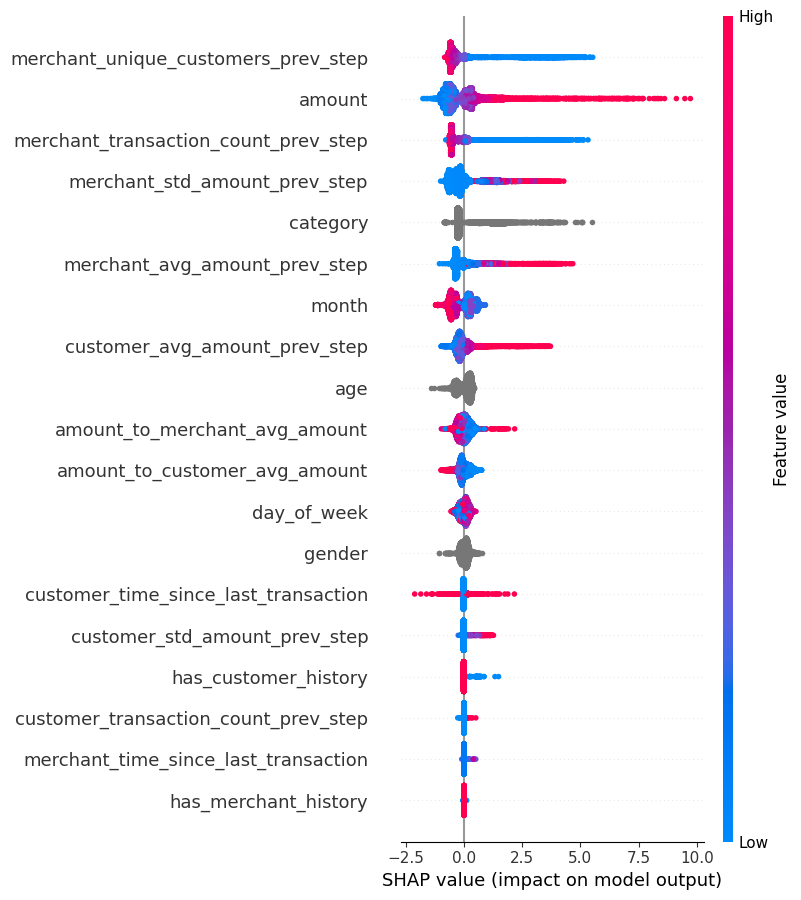

In [15]:
X = trans[
    cat.feature_names_
].copy()

X_sample = X.sample(
    n=10_000,
    random_state=42
)

explainer = shap.TreeExplainer(cat)
shap_values = explainer.shap_values(
    X_sample
)

shap.summary_plot(
    shap_values,
    X_sample
)

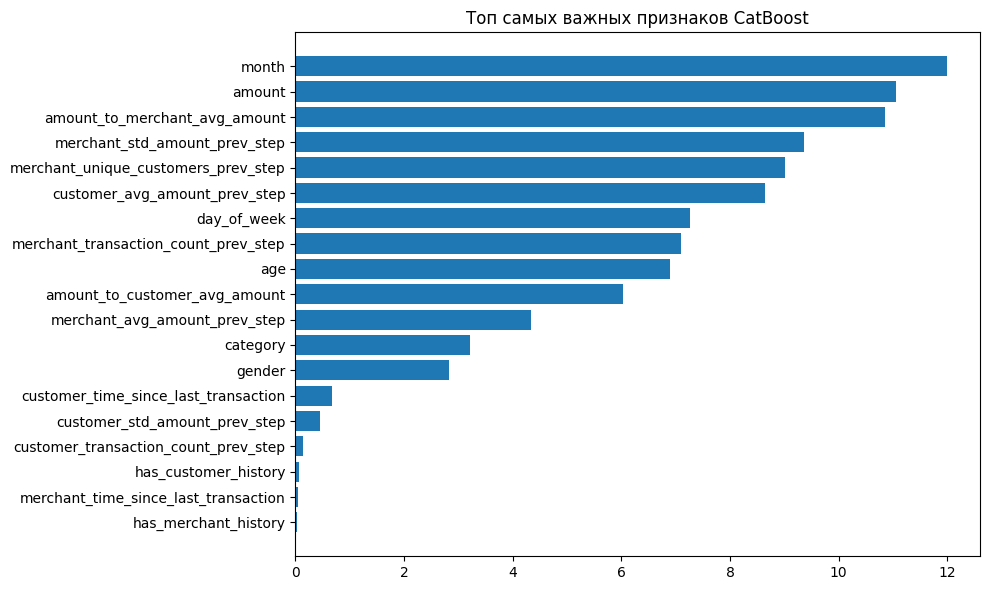

In [16]:
feature_importance = pd.Series(cat.get_feature_importance(), index=cat.feature_names_).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.index, feature_importance.values)
plt.title("Топ самых важных признаков CatBoost")
plt.tight_layout()

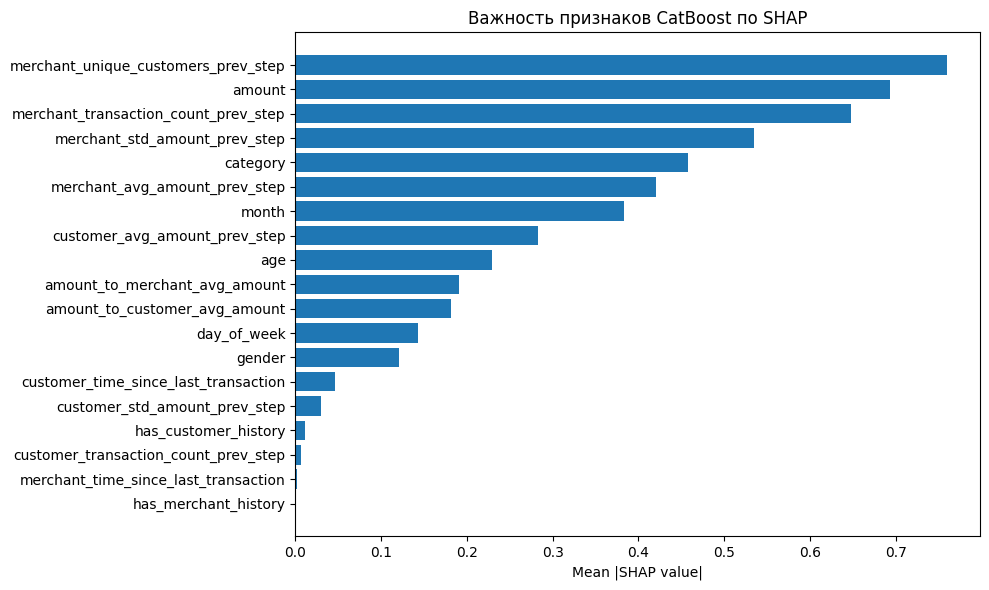

In [17]:
pool = Pool(
    X_sample,
    cat_features=categorical_features
)

shap_values = cat.get_feature_importance(
    type="ShapValues",
    data=pool
)

shap_values = shap_values[:, :-1]

feature_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=cat.feature_names_
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance.index,
    feature_importance.values
)

plt.title("Важность признаков CatBoost по SHAP")
plt.xlabel("Mean |SHAP value|")

plt.tight_layout()
plt.show()

## Проведем Error analysis

In [ ]:
def make_error_analysis(artifact_path, df=trans):
    artifact = joblib.load(ARTIFACTS / artifact_path)
    cat = artifact["model"]
    threshold = artifact["metadata"]["threshold"]

    features = cat.feature_names_

    _, test = make_train_test_split(
        df,
        train_size=TRAIN_SIZE
    )

    X_test = test.loc[:, features].copy()
    y_test = test["fraud"]
    test_amounts = test["amount"]

    test_proba = cat.predict_proba(X_test)[:, 1]
    test_predict = (test_proba >= threshold).astype(int)

    fraud_mask = (y_test == 1)
    
    total_fraud_amount = test_amounts[fraud_mask].sum()
    skipped_fraud_amount = test_amounts[
        fraud_mask & (test_predict == 0)
    ].sum()
    cought_fraud_amount_fr = compute_fraud_amount_recall(y_test, test_predict, test_amounts)
    cought_fraud_amount = cought_fraud_amount_fr * total_fraud_amount

    print(f"Общая сумма пойманных фродовых транзакций: {cought_fraud_amount}")
    print(f"Общая сумма пропущенных фродовых транзакций: {skipped_fraud_amount}")
    print(f"Общая доля суммы пойманных фродовых транзакций: {cought_fraud_amount_fr}")
    print("______________________________________________________________________________________")
    for category in X_test["category"].unique():
        print(f"{category}:")
        category_fraud_mask = (y_test == 1) & (X_test["category"] == category)

        cought_fraud_amount = test_amounts[
            category_fraud_mask & (test_predict == 1)
        ].sum()

        skipped_fraud_amount = test_amounts[
            category_fraud_mask & (test_predict == 0)
        ].sum()

        total_fraud_amount = test_amounts[
            category_fraud_mask
        ].sum()

        cought_fraud_amount_fr = None
        if total_fraud_amount > 0:
            cought_fraud_amount_fr = cought_fraud_amount / total_fraud_amount

        _, _, test_fn, test_tp = confusion_matrix(
            y_test[X_test["category"] == category],
            test_predict[X_test["category"] == category],
            labels=[0, 1]
        ).ravel()

        test_fnr = (
            test_fn / (test_tp + test_fn)
            if (test_tp + test_fn) > 0
            else 0
        )

        print(f"Сумма пойманных фродовых транзакций для категории: {cought_fraud_amount}")
        print(f"Доля суммы пойманных фродовых транзакций для категории: {cought_fraud_amount_fr}")
        print(f"Cумма пропущенных фродовых транзакций для категории: {skipped_fraud_amount}")
        print(f"Доля пропущенных фродовых транзакций для категории: {test_fnr}")
        print("______________________________________________________________________________________")


In [14]:
make_error_analysis("catboost_4.1.joblib")

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Общая сумма пропущенных фродовых транзакций: 29520.420000000002
Общая доля суммы пойманных фродовых транзакций: 0.9610491124516046
______________________________________________________________________________________
es_health:
Доля суммы пойманных фродовых транзакций для категории: 0.9626943949639776
Cумма пропущенных фродовых транзакций для категории: 5051.02
Доля пропущенных фродовых транзакций для категории: 0.12931034482758622
______________________________________________________________________________________
es_home:
Доля суммы пойманных фродовых транзакций для категории: 0.8713739161374514
Cумма пропущенных фродовых транзакций для категории: 2718.5200000000004
Доля пропущенных фродовых транзакций для категории: 0.3392857142857143
______________________________________________________________________________________
es_wellnessandbeauty:
Доля суммы пойманных фродовых транзакций для категории: 0.84665013

In [ ]:
make_error_analysis("catboost_8.joblib")
# es_barsandrestaurants
# es_hyper

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Общая сумма пропущенных фродовых транзакций: 23583.27
Общая доля суммы пойманных фродовых транзакций: 0.9688829190847066
______________________________________________________________________________________
es_health:
Доля суммы пойманных фродовых транзакций для категории: 0.9792597610530434
Cумма пропущенных фродовых транзакций для категории: 2808.1400000000003
Доля пропущенных фродовых транзакций для категории: 0.09770114942528736
______________________________________________________________________________________
es_home:
Доля суммы пойманных фродовых транзакций для категории: 0.8963253475504683
Cумма пропущенных фродовых транзакций для категории: 2191.17
Доля пропущенных фродовых транзакций для категории: 0.26785714285714285
______________________________________________________________________________________
es_wellnessandbeauty:
Доля суммы пойманных фродовых транзакций для категории: 0.8660413264383758


In [16]:
make_error_analysis("catboost_9.joblib")
# es_barsandrestaurants
# es_hyper

Train: 457,744
Test:  136,899
Train steps: 0 - 142
Test steps:  143 - 179
Общая сумма пропущенных фродовых транзакций: 22052.85
Общая доля суммы пойманных фродовых транзакций: 0.9709022405348017
______________________________________________________________________________________
es_health:
Доля суммы пойманных фродовых транзакций для категории: 0.9814599041299231
Cумма пропущенных фродовых транзакций для категории: 2510.25
Доля пропущенных фродовых транзакций для категории: 0.08620689655172414
______________________________________________________________________________________
es_home:
Доля суммы пойманных фродовых транзакций для категории: 0.9013856596574603
Cумма пропущенных фродовых транзакций для категории: 2084.2200000000003
Доля пропущенных фродовых транзакций для категории: 0.26785714285714285
______________________________________________________________________________________
es_wellnessandbeauty:
Доля суммы пойманных фродовых транзакций для категории: 0.877069884716429
C